In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import numpy 
import os
from matplotlib.ticker import MultipleLocator
from matplotlib.dates import DateFormatter
import numpy as np

In [ ]:
def extract_job_info(job_id,jobs_df,target_metrics):
    job_data = jobs_df[jobs_df['job_rec_id'] == job_id]
    info = {}
    
    for metric in target_metrics:
        metric_data = job_data[job_data['metric'] == metric]
        if not metric_data.empty:
            if metric in ['submit_job', 'job_epilog_complete', 'launch_job']:
                info[metric] = metric_data['t'].iloc[0]
            else:
                info[metric] = metric_data['value'].iloc[0]
        else:
            info[metric] = None
    return info

def calculate_metrics(result_dir):

    
    
    df = pd.read_csv(result_dir);
    jobs = df[df['job_rec_id'].notna()].copy()
    jobs['job_rec_id'] = jobs['job_rec_id'].astype(int)
    total_jobs = jobs['job_rec_id'].nunique()
    #print(f"\njobs sum: {total_jobs}")
    
    target_metrics = ['job_name', 'job_id','uid', 'launch_job', 'submit_job', 'job_epilog_complete', 'carbon_emissions', 'carbon_emissions_actual']
    
    jobs_df = df[df['job_rec_id'].notna()].copy()
    jobs_df['job_rec_id'] = jobs_df['job_rec_id'].astype(int)
    
    job_ids = jobs_df['job_rec_id'].unique()
    job_info_list = [extract_job_info(job_id,jobs_df,target_metrics) for job_id in sorted(job_ids)]
    job_summary = pd.DataFrame(job_info_list)
    job_summary = job_summary.rename(columns={'job_rec_id': 'job_id'})
    
    if all(col in job_summary.columns for col in ['submit_job', 'job_epilog_complete']):
        job_summary['job_epilog_complete'] = job_summary['job_epilog_complete']
        job_summary['job_completion_time'] = (job_summary['job_epilog_complete'] - job_summary['submit_job'])
        job_summary['job_waiting_time'] = (job_summary['launch_job'] - job_summary['submit_job'])
    #display(job_summary)
    
    
    
    #performance metrics
    print("\n********Performance metrics********\n")
    
    total_waiting_time_sum = 0
    if 'job_waiting_time' in job_summary.columns:
        job_summary['job_waiting_time'] = pd.to_numeric(job_summary['job_waiting_time'])
        total_waiting_time_sum = job_summary['job_waiting_time'].sum() / 3600
        #print(f"jobs total_waiting_time_sum sum: {total_waiting_time_sum:.5f}h\n")

    max_wait = job_summary['job_waiting_time'].max()
    #print(f"max job waiting time: {max_wait:.5f}s\n")
    min_wait = job_summary['job_waiting_time'].min()
    #print(f"min job waiting time: {min_wait:.5f}s\n")
    
    per_job_waiting_time = total_waiting_time_sum/total_jobs
    #print(f"per job waiting time: {per_job_waiting_time:.2f}/h\n")
    
    
    total_completion_time_sum = 0
    if 'job_completion_time' in job_summary.columns:
        job_summary['job_completion_time'] = pd.to_numeric(job_summary['job_completion_time'])
        total_completion_time_sum = job_summary['job_completion_time'].sum() / 3600
        #print(f"jobs total_completion_time sum: {total_completion_time_sum:.5f}h\n")
    
   


    begin_time = job_summary['submit_job'].min()
    end_time = job_summary['job_epilog_complete'].max()
    complete_through_time_seconds = (end_time - begin_time)
    complete_through_time_hours = complete_through_time_seconds / 3600
    #print(f"begin time: {begin_time}, end time: {end_time}, job finish time: {complete_through_time_seconds}/s\n")
    job_throughput_per_h = total_jobs / complete_through_time_hours
    #print(f"job througput: {round(job_throughput_per_h)}/h\n")
    
    #carbon emissions metrics
    print("\n********Carbon emissions metrics********\n")
    total_emissions_sum = 0
    count_filtered_job = 0
    if 'carbon_emissions_actual' in job_summary.columns:
        job_summary['carbon_emissions_actual'] = pd.to_numeric(job_summary['carbon_emissions_actual'])
        count_filtered_job = (job_summary['carbon_emissions_actual'] > 150).sum()
        # Filter out rows where emissions > 15
        filtered_job_summary = job_summary[job_summary['carbon_emissions_actual'] <= 150]
        
        total_emissions_sum = filtered_job_summary['carbon_emissions_actual'].sum() 
        print(f"jobs total emissions sum (filtered <=100kg): {total_emissions_sum:.2f}g\n")

    total_emissions_sum_submit = 0
    count_filtered_job_submit = 0
    if 'carbon_emissions' in job_summary.columns:
        job_summary['carbon_emissions'] = pd.to_numeric(job_summary['carbon_emissions'])
        count_filtered_job_submit = (job_summary['carbon_emissions'] > 150).sum()
        # Filter out rows where emissions > 150
        filtered_job_summary_submit = job_summary[job_summary['carbon_emissions'] <= 150]
        
        total_emissions_sum_submit = filtered_job_summary_submit['carbon_emissions'].sum() 
        print(f"jobs total emissions sum submit (filtered <=100kg): {total_emissions_sum_submit:.2f}g\n")


    emissions_rate_kg_per_h = 0
    if total_completion_time_sum > 0:
        emissions_rate_kg_per_h = total_emissions_sum / complete_through_time_hours
        #print(f"emissions rate: {emissions_rate_kg_per_h:.4f} g/h\n") 
    else:
        print("error：competion time is 0，can not calculate the emissions rate\n")
    
    emissions_rate_per_job = (total_emissions_sum) / (total_jobs - count_filtered_job)
    #print(f"job emissions througput: {emissions_rate_per_job:.2f}g per job\n")

    result_metrics = {'total_waiting_time_sum': total_waiting_time_sum, 'per_job_waiting_time': per_job_waiting_time,'total_completion_time': complete_through_time_seconds, 
                      'max_waiting_time': max_wait, 'min_waiting_time': min_wait,
                      'job_throughput_per_h': job_throughput_per_h, 'total_emissions_sum': total_emissions_sum, 'total_emissions_sum_submit':total_emissions_sum_submit,
                     'emissions_rate_per_job': emissions_rate_per_job, 'min_waiting_time': min_wait, 'max_waiting_time': max_wait,
                     'average_waiting_time': per_job_waiting_time }
    return result_metrics

In [9]:
# 2024-12-15
ci_dir_5am = "result/2024-12-15/ci_new_5am_slurmctld_log.csv"
backfill_dir_5am = "result/2024-12-15/backfill_5am_slurmctld_log.csv"
fifo_dir_5am =  "result/2024-12-15/fifo_5am_slurmctld_log.csv"
saf_timenorm_dir_5am = "result/2024-12-15/saf-time_5am_slurmctld_log.csv"
saf_dir_5am = "result/2024-12-15/saf_5am_slurmctld_log.csv"
ci_result_5am = calculate_metrics(ci_dir_5am)
fifo_result_5am = calculate_metrics(fifo_dir_5am)
backfill_result_5am = calculate_metrics(backfill_dir_5am)
saf_timenorm_result_5am = calculate_metrics(saf_timenorm_dir_5am)
saf_result_5am = calculate_metrics(saf_dir_5am)


ci_dir_8am = "result/2024-12-15/ci_new_8am_slurmctld_log.csv"
backfill_dir_8am = "result/2024-12-15/backfill_8am_slurmctld_log.csv"
fifo_dir_8am =  "result/2024-12-15/fifo_8am_slurmctld_log.csv"
saf_timenorm_dir_8am = "result/2024-12-15/saf-time_8am_slurmctld_log.csv"
saf_dir_8am = "result/2024-12-15/saf_8am_slurmctld_log.csv"
ci_result_8am = calculate_metrics(ci_dir_8am)
fifo_result_8am = calculate_metrics(fifo_dir_8am)
backfill_result_8am = calculate_metrics(backfill_dir_8am)
saf_timenorm_result_8am = calculate_metrics(saf_timenorm_dir_8am)
saf_result_8am = calculate_metrics(saf_dir_8am)


ci_dir_1pm = "result/2024-12-15/ci_new_1pm_slurmctld_log.csv"
backfill_dir_1pm = "result/2024-12-15/backfill_1pm_slurmctld_log.csv"
fifo_dir_1pm =  "result/2024-12-15/fifo_1pm_slurmctld_log.csv"
saf_timenorm_dir_1pm = "result/2024-12-15/saf-time_1pm_slurmctld_log.csv"
saf_dir_1pm = "result/2024-12-15/saf_1pm_slurmctld_log.csv"
ci_result_1pm = calculate_metrics(ci_dir_1pm)
fifo_result_1pm = calculate_metrics(fifo_dir_1pm)
backfill_result_1pm = calculate_metrics(backfill_dir_1pm)
saf_timenorm_result_1pm = calculate_metrics(saf_timenorm_dir_1pm)
saf_result_1pm = calculate_metrics(saf_dir_1pm)


ci_dir_6pm = "result/2024-12-15/ci_new_6pm_slurmctld_log.csv"
backfill_dir_6pm = "result/2024-12-15/backfill_6pm_slurmctld_log.csv"
fifo_dir_6pm =  "result/2024-12-15/fifo_6pm_slurmctld_log.csv"
saf_timenorm_dir_6pm = "result/2024-12-15/saf-time_6pm_slurmctld_log.csv"
saf_dir_6pm = "result/2024-12-15/saf_6pm_slurmctld_log.csv"
ci_result_6pm = calculate_metrics(ci_dir_6pm)
fifo_result_6pm = calculate_metrics(fifo_dir_6pm)
backfill_result_6pm = calculate_metrics(backfill_dir_6pm)
saf_timenorm_result_6pm = calculate_metrics(saf_timenorm_dir_6pm)
saf_result_6pm = calculate_metrics(saf_dir_6pm)





********Performance metrics********


********Carbon emissions metrics********

jobs total emissions sum (filtered <=100kg): 141.29g

jobs total emissions sum submit (filtered <=100kg): 130.28g


********Performance metrics********


********Carbon emissions metrics********

jobs total emissions sum (filtered <=100kg): 126.71g

jobs total emissions sum submit (filtered <=100kg): 129.80g


********Performance metrics********


********Carbon emissions metrics********

jobs total emissions sum (filtered <=100kg): 141.02g

jobs total emissions sum submit (filtered <=100kg): 127.10g


********Performance metrics********


********Carbon emissions metrics********

jobs total emissions sum (filtered <=100kg): 123.23g

jobs total emissions sum submit (filtered <=100kg): 124.52g


********Performance metrics********


********Carbon emissions metrics********

jobs total emissions sum (filtered <=100kg): 119.07g

jobs total emissions sum submit (filtered <=100kg): 130.18g


********Performance

In [4]:
index = ['Carbon-Aware', 'FIFO', 'BACKFILL', 'SAF-TimeNorm','SAF']
colors = ['dodgerblue','gray','green','purple','orange']
time_labels = ['5am', '8am', '1pm', '6pm'] 


def draw_chart(index, colors, value_name, y_label_title, results, time_labels, main_title):
    fig, axes = plt.subplots(2, 2, figsize=(16, 10)) 
    axes = axes.flatten()
    fig.suptitle(main_title, fontsize=14, y=1.02)
    
    all_values = []
    for result in results:
        for key in ['ci', 'fifo', 'backfill', 'saf_timenorm', 'saf']:
            try:
                all_values.append(result[key][value_name])
            except (KeyError, TypeError):
                all_values.append(0)
    
    y_max = max(all_values) * 1.05 if all_values else 1
    
    for i, (result, time_label) in enumerate(zip(results, time_labels)):
        values = []
        for key in ['ci', 'fifo', 'backfill', 'saf_timenorm', 'saf']:
            try:
                values.append(result[key][value_name])
            except (KeyError, TypeError):
                values.append(0)  
                print(f"error: {key} or {value_name} doesn't exist in {time_label} results")
  
        bars = axes[i].bar(index, values, zorder=3)
        axes[i].set_title(time_label)
        axes[i].set_ylabel(y_label_title)
        axes[i].set_ylim(0, y_max) 
        
        for j in range(len(index)):
            bars[j].set_color(colors[j])
        
        axes[i].grid(axis='y', alpha=0.7, zorder=0)

    save_dir = "/Users/amber/slurm_work"
    save_path = os.path.join(save_dir, f"{value_name}.png")

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches='tight',
        facecolor='white'
    )
    #print(f"save to : {save_path}")
    plt.show()
    plt.close()



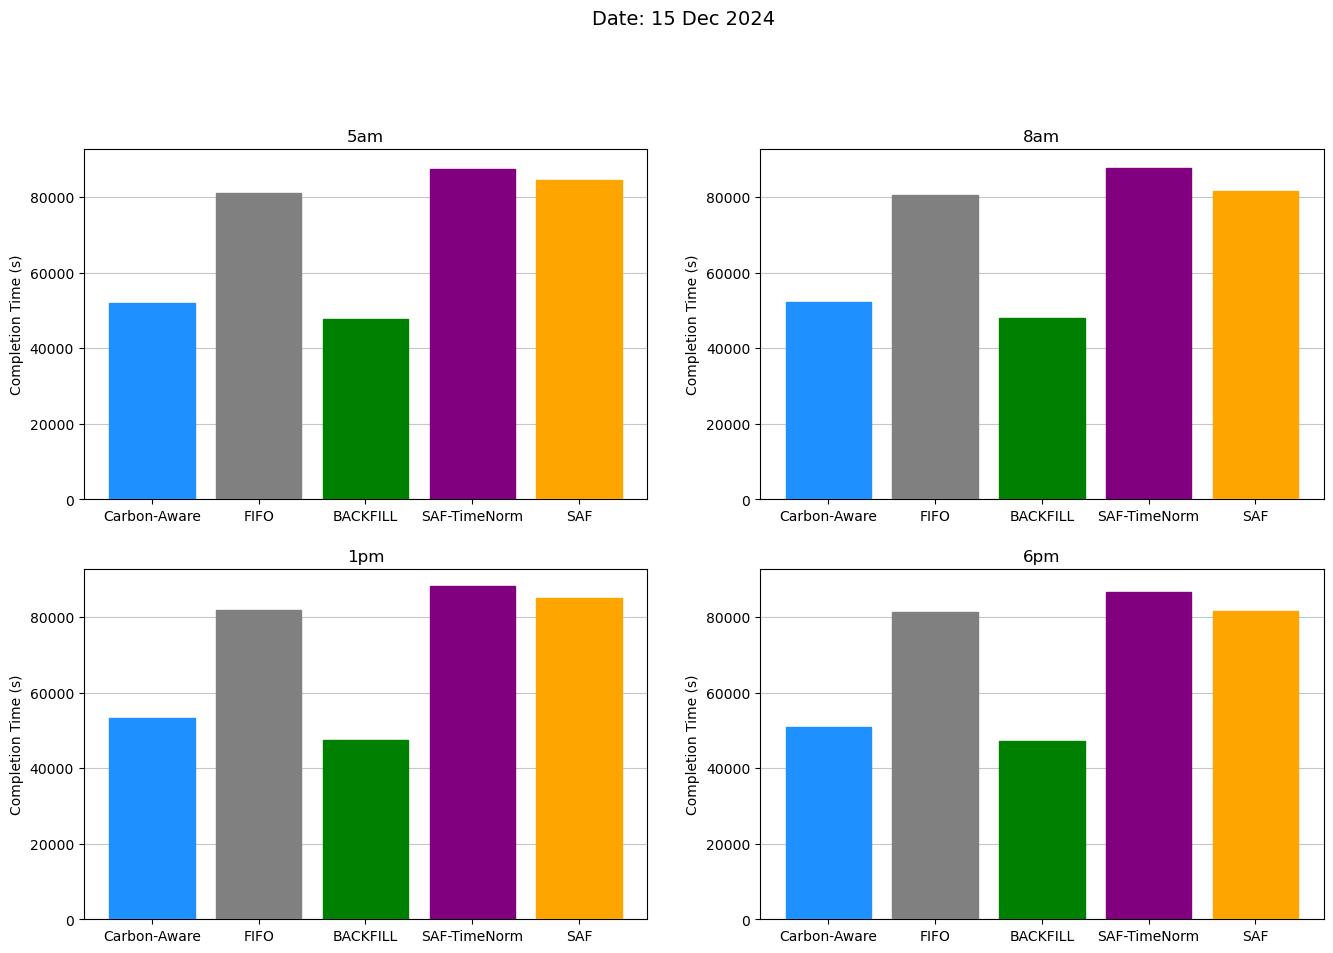

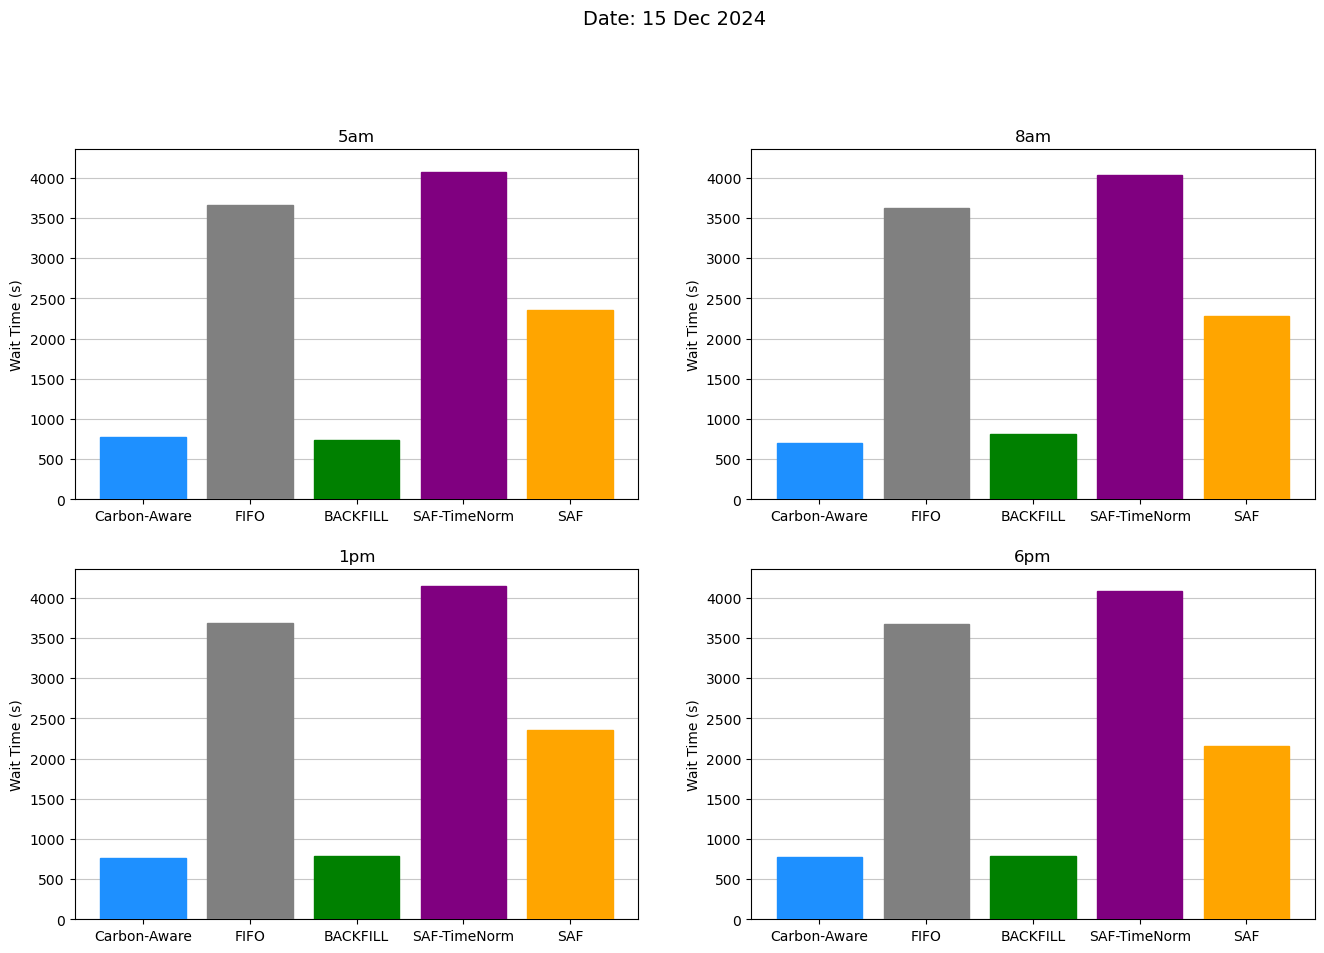

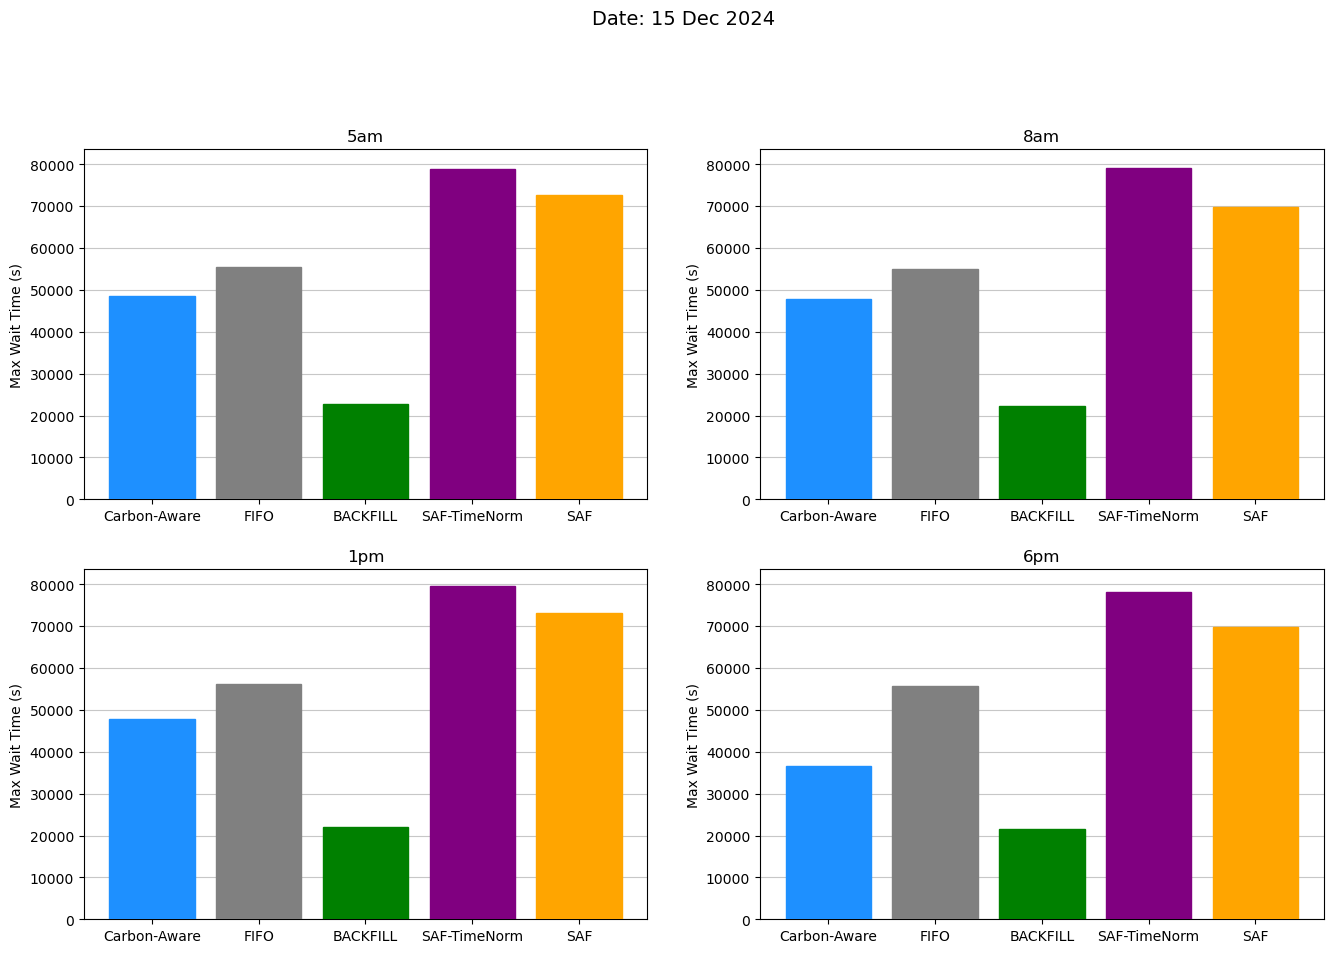

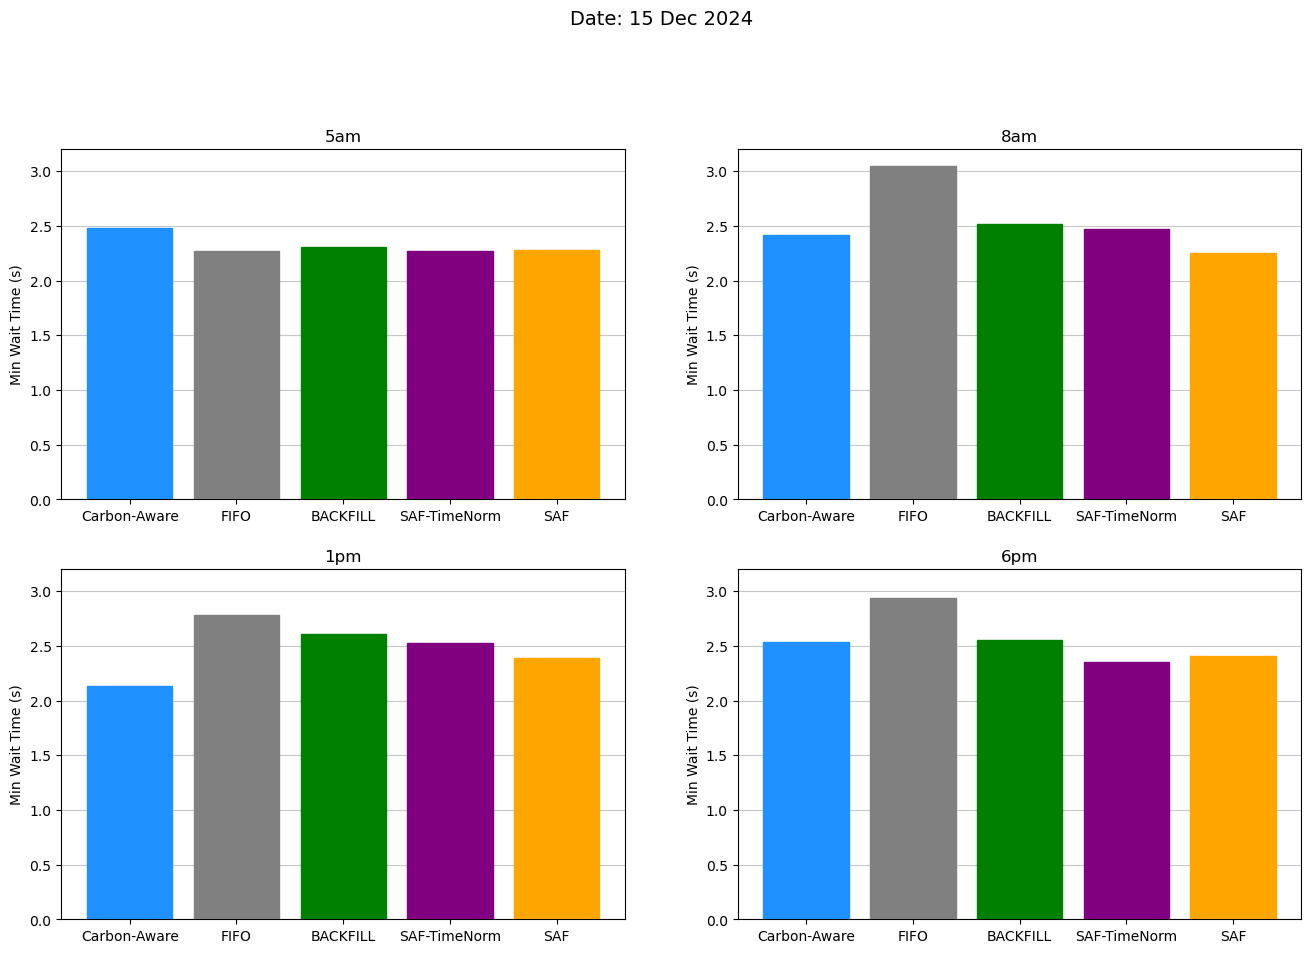

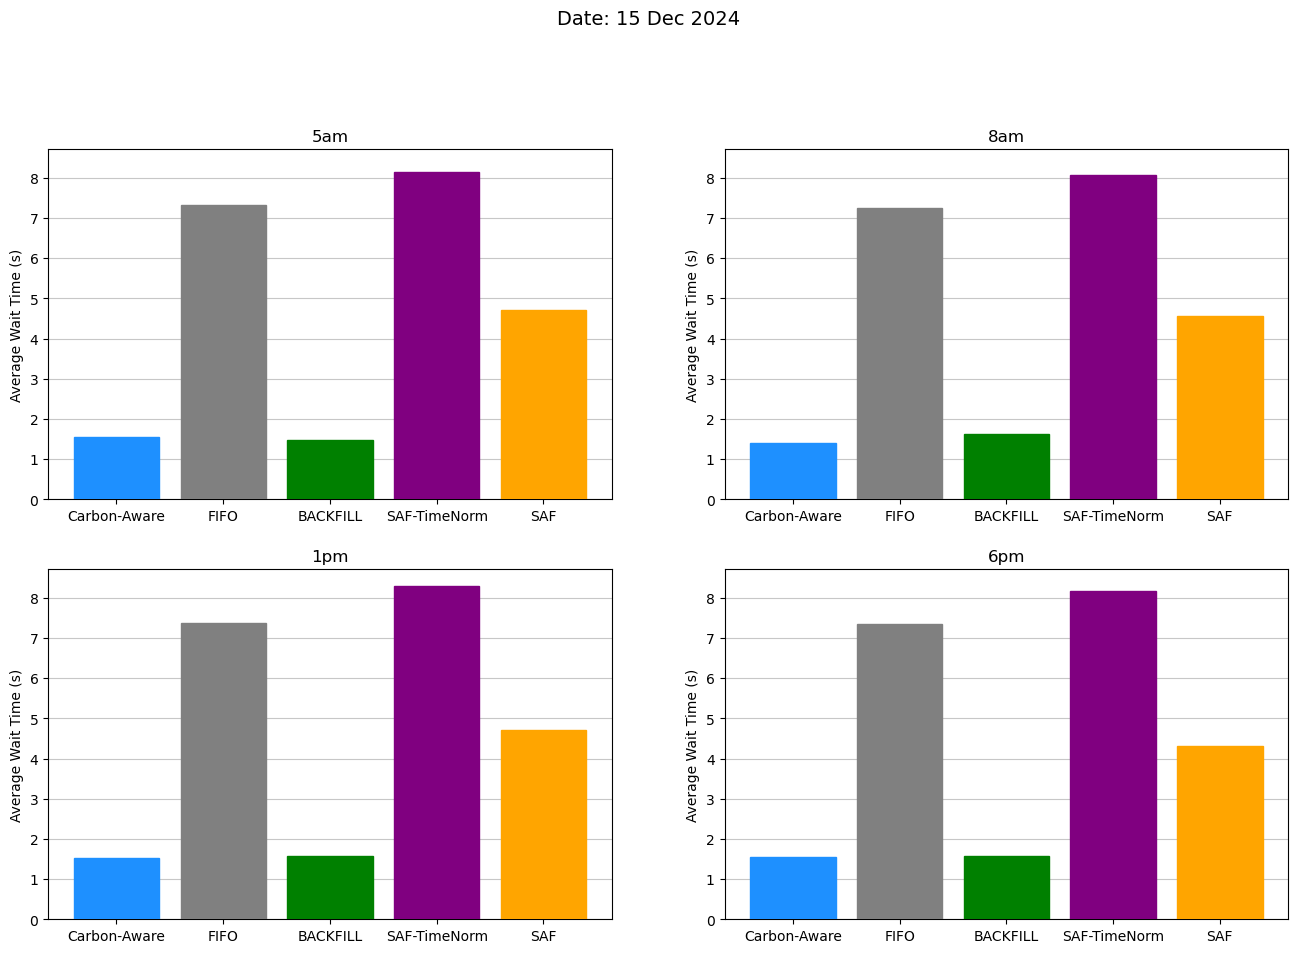

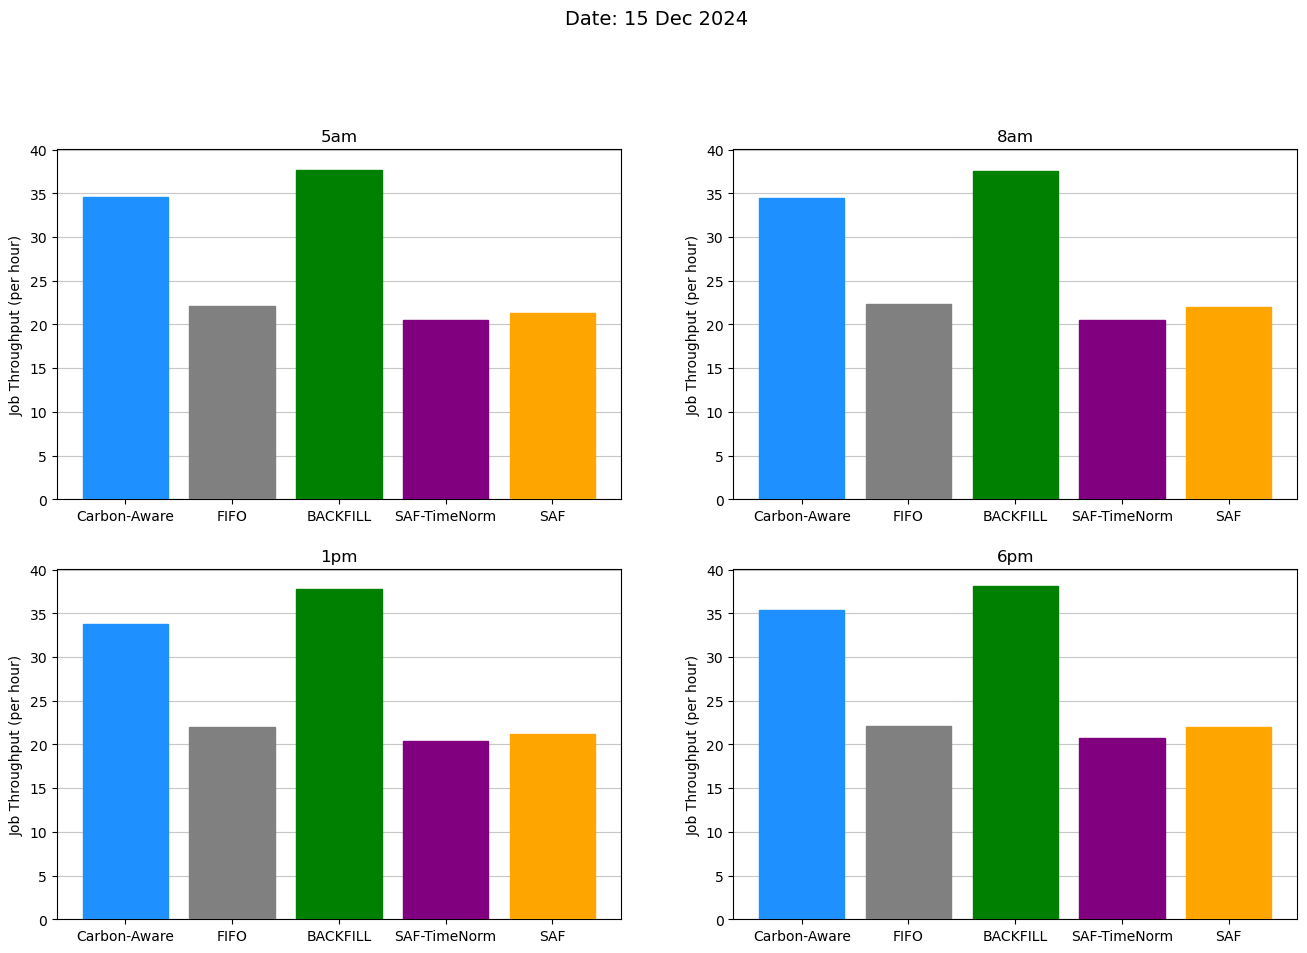

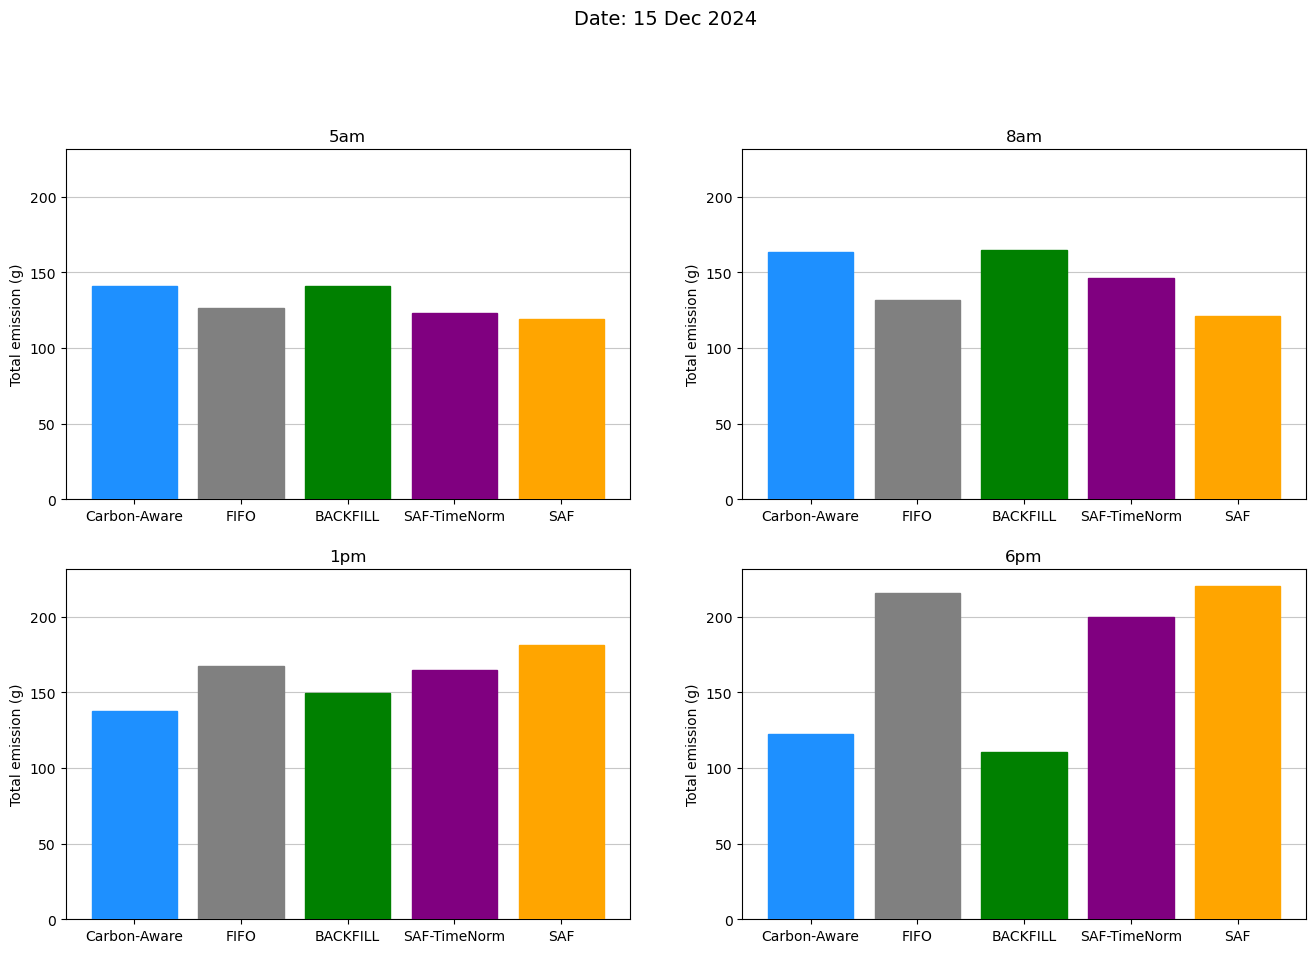

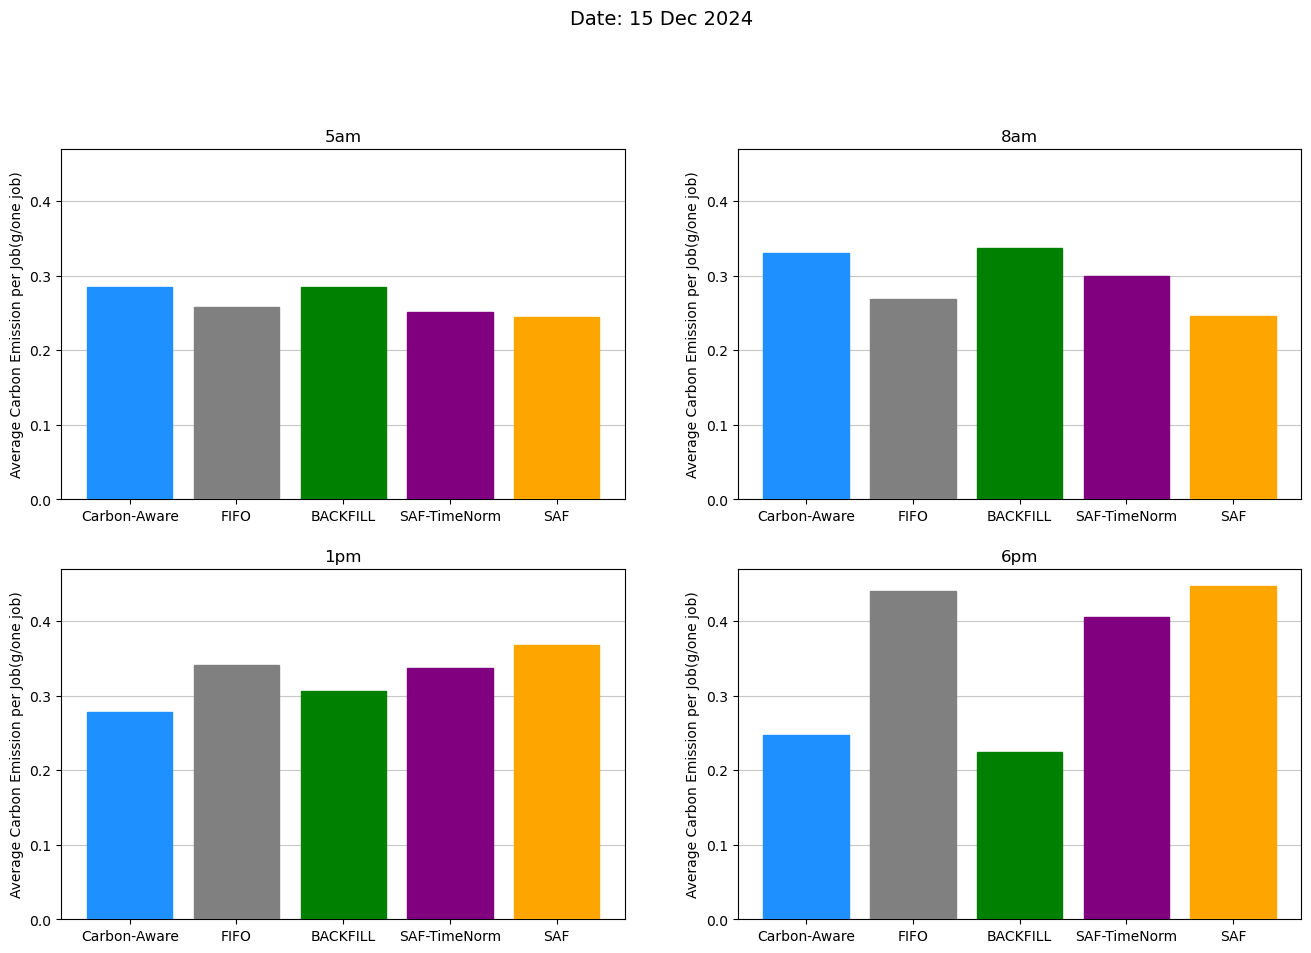

In [11]:
#2024-12-15

results_5am = {'ci': ci_result_5am,'fifo':fifo_result_5am,'backfill':backfill_result_5am,
               'saf_timenorm':saf_timenorm_result_5am,'saf':saf_result_5am}

results_8am = {'ci': ci_result_8am,'fifo':fifo_result_8am,'backfill':backfill_result_8am,
               'saf_timenorm':saf_timenorm_result_8am,'saf':saf_result_8am}

results_1pm = {'ci': ci_result_1pm,'fifo':fifo_result_1pm,'backfill':backfill_result_1pm,
               'saf_timenorm':saf_timenorm_result_1pm,'saf':saf_result_1pm}

results_6pm = {'ci': ci_result_6pm,'fifo':fifo_result_6pm,'backfill':backfill_result_6pm,
               'saf_timenorm':saf_timenorm_result_6pm,'saf':saf_result_6pm}

results = [results_5am, results_8am, results_1pm, results_6pm]

#completion time comparison
draw_chart(index,colors, 'total_completion_time', 'Completion Time (s)', results, time_labels, "Date: 15 Dec 2024")
#waiting time comparison
draw_chart(index,colors, 'total_waiting_time_sum', 'Wait Time (s)', results, time_labels, "Date: 15 Dec 2024")
#max waiting time comparison
draw_chart(index,colors, 'max_waiting_time', 'Max Wait Time (s)', results, time_labels, "Date: 15 Dec 2024")
#min waiting time comparison
draw_chart(index,colors, 'min_waiting_time', 'Min Wait Time (s)', results, time_labels, "Date: 15 Dec 2024")
#average waiting time comparison
draw_chart(index,colors, 'average_waiting_time', 'Average Wait Time (s)', results, time_labels, "Date: 15 Dec 2024")
#job throughput comparison
draw_chart(index,colors, 'job_throughput_per_h', 'Job Throughput (per hour)', results, time_labels, "Date: 15 Dec 2024")
#total emissions comparison
draw_chart(index,colors, 'total_emissions_sum', 'Total emission (g)', results, time_labels, "Date: 15 Dec 2024")
#emissions_rate_kg_per_h comparison
#draw_chart(index,colors, 'emissions_rate_kg_per_h', 'Emission Rate (g/h)', results, time_labels, "Date: 2024-12-15")
#emissions_rate_per_job emissions throughput comparison
draw_chart(index,colors, 'emissions_rate_per_job', 'Average Carbon Emission per Job(g/one job)', results, time_labels, "Date: 15 Dec 2024")

In [25]:
def draw_chart_one(index, colors, value_name, y_label_title, result, time_label, main_title):
    fig, ax = plt.subplots(figsize=(8, 6))  
    fig.suptitle(main_title, fontsize=14, y=1.02)
    
    all_values = []
    for key in ['ci', 'fifo', 'backfill', 'saf_timenorm', 'saf']:
        try:
            all_values.append(result[key][value_name])
        except (KeyError, TypeError):
            all_values.append(0)
    
    y_max = max(all_values) * 1.05 if all_values else 1

    values = []
    for key in ['ci', 'fifo', 'backfill', 'saf_timenorm', 'saf']:
        try:
            values.append(result[key][value_name])
        except (KeyError, TypeError):
            values.append(0)

    bars = ax.bar(index, values, zorder=3)
    ax.set_title(time_label)  
    ax.set_ylabel(y_label_title)
    ax.set_ylim(0, y_max)
    
    for j in range(len(index)):
        bars[j].set_color(colors[j])
    
    ax.grid(axis='y', alpha=0.7, zorder=0)
    plt.show()
    plt.close()

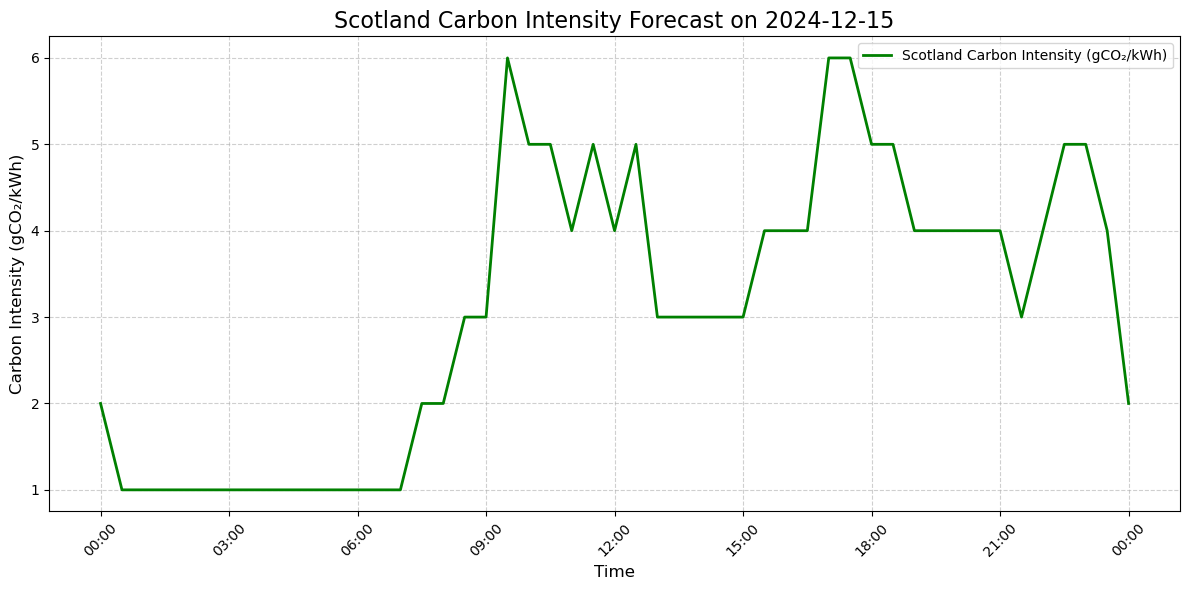

In [34]:
df = pd.read_csv('result/Carbon_Intensity_Data.csv')

df['Datetime (UTC)'] = pd.to_datetime(df['Datetime (UTC)'])
scotland_data = df[['Datetime (UTC)', 'Scotland']]

plt.figure(figsize=(12, 6))
plt.plot(
    scotland_data['Datetime (UTC)'],  
    scotland_data['Scotland'],
    label='Scotland Carbon Intensity (gCO₂/kWh)',
    color='green',  
    linestyle='-',
    linewidth=2
)

plt.title('Scotland Carbon Intensity Forecast on 2024-12-15', fontsize=16)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Carbon Intensity (gCO₂/kWh)', fontsize=12)


time_format = DateFormatter('%H:%M')  
plt.gca().xaxis.set_major_formatter(time_format)

plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

value_name = "carbon_intensity_forecast"
save_dir = "/Users/amber/slurm_work"
save_path = os.path.join(save_dir, f"{value_name}.png")

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()
plt.close()


********Performance metrics********


********Carbon emissions metrics********

jobs total emissions sum (filtered <=100kg): 5813.47g

jobs total emissions sum submit (filtered <=100kg): 5593.81g


********Performance metrics********


********Carbon emissions metrics********

jobs total emissions sum (filtered <=100kg): 5105.74g

jobs total emissions sum submit (filtered <=100kg): 5314.70g


********Performance metrics********


********Carbon emissions metrics********

jobs total emissions sum (filtered <=100kg): 5806.50g

jobs total emissions sum submit (filtered <=100kg): 5407.81g


********Performance metrics********


********Carbon emissions metrics********

jobs total emissions sum (filtered <=100kg): 5194.66g

jobs total emissions sum submit (filtered <=100kg): 5475.26g


********Performance metrics********


********Carbon emissions metrics********

jobs total emissions sum (filtered <=100kg): 5802.62g

jobs total emissions sum submit (filtered <=100kg): 5353.73g


********P

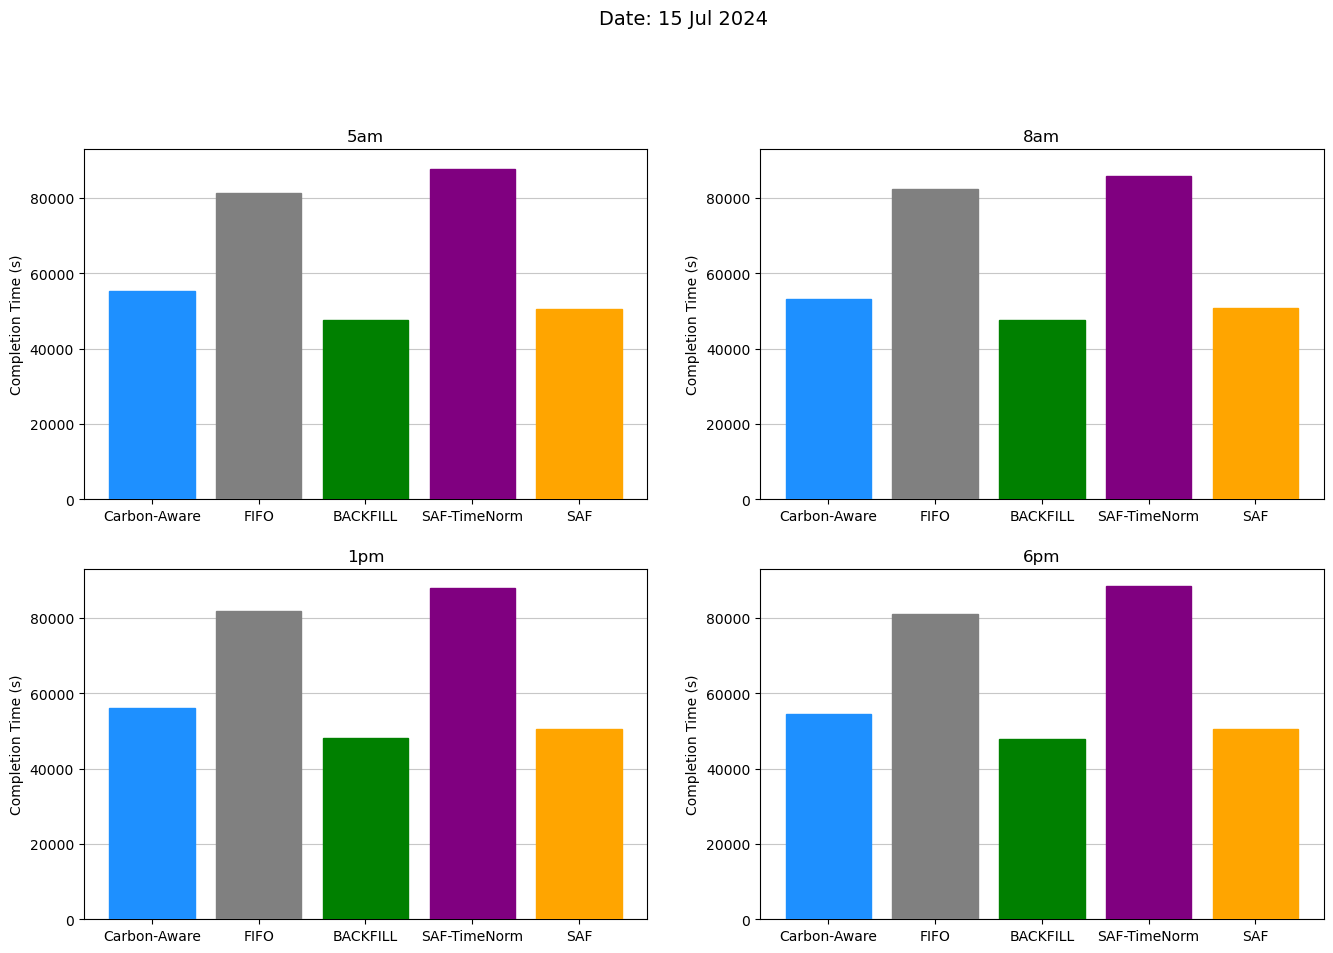

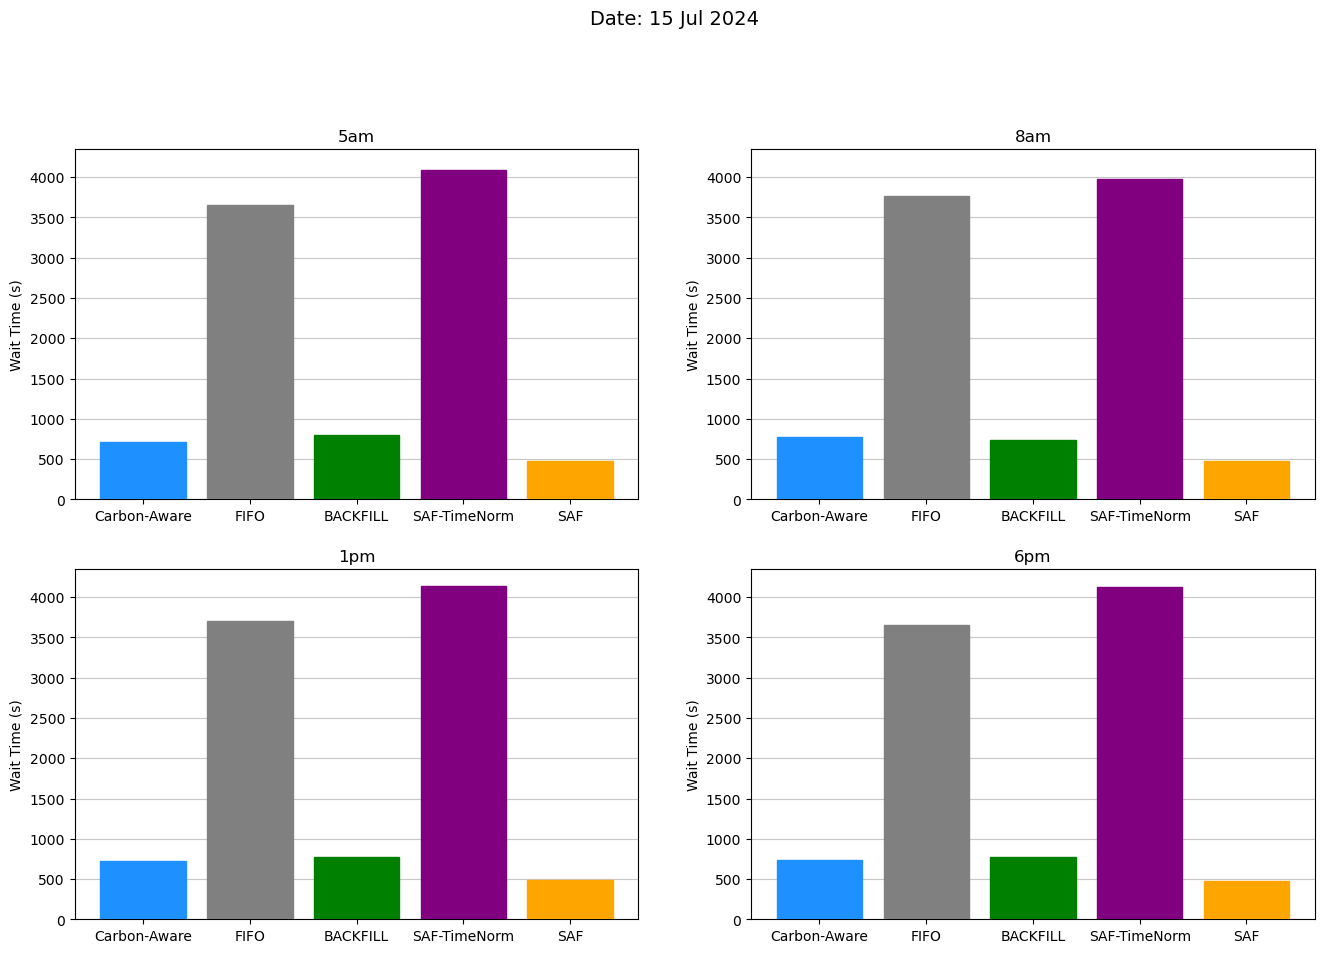

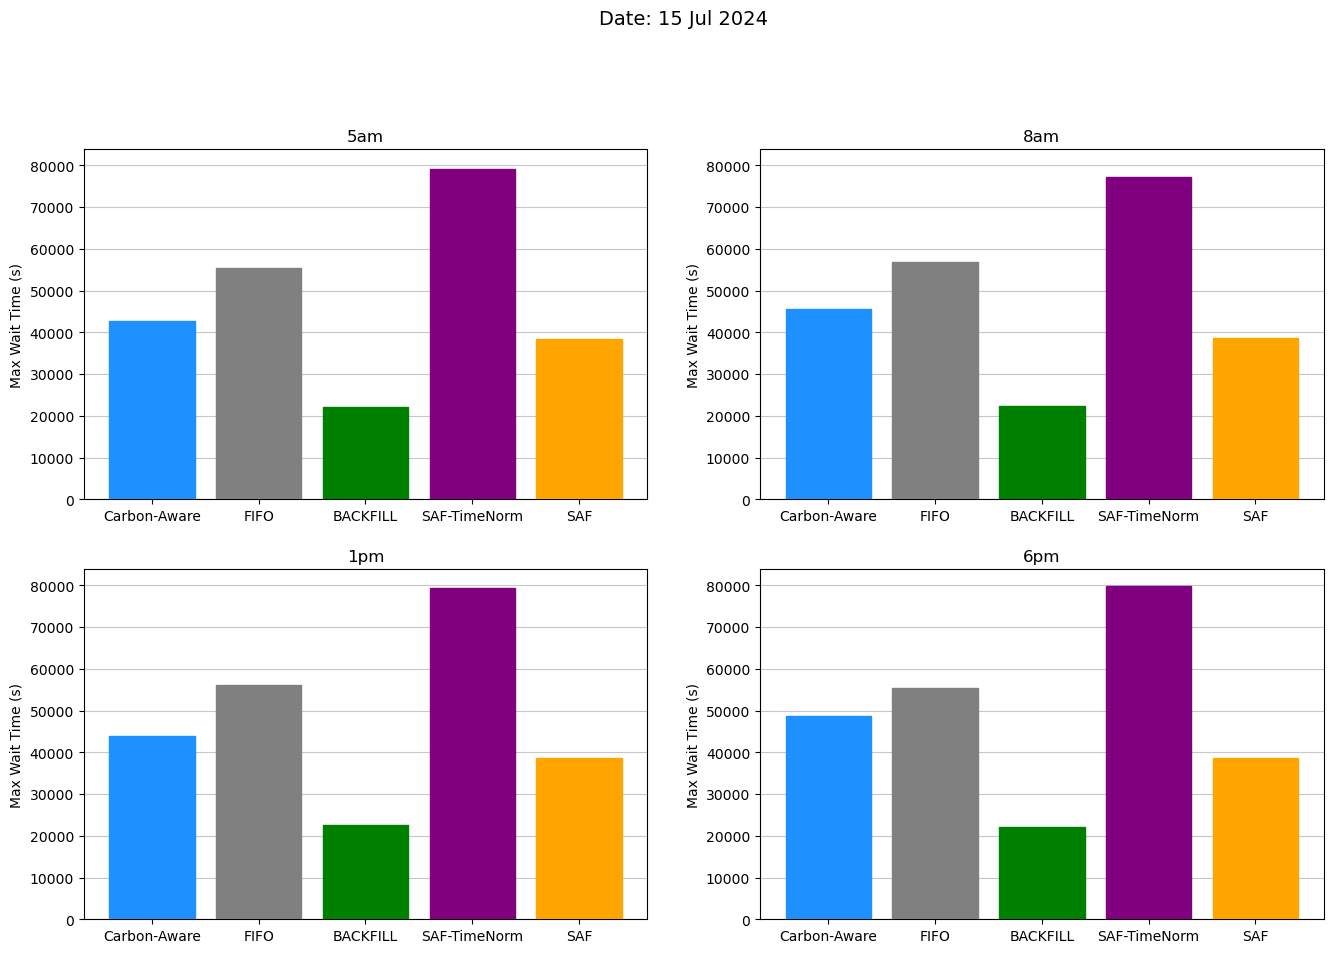

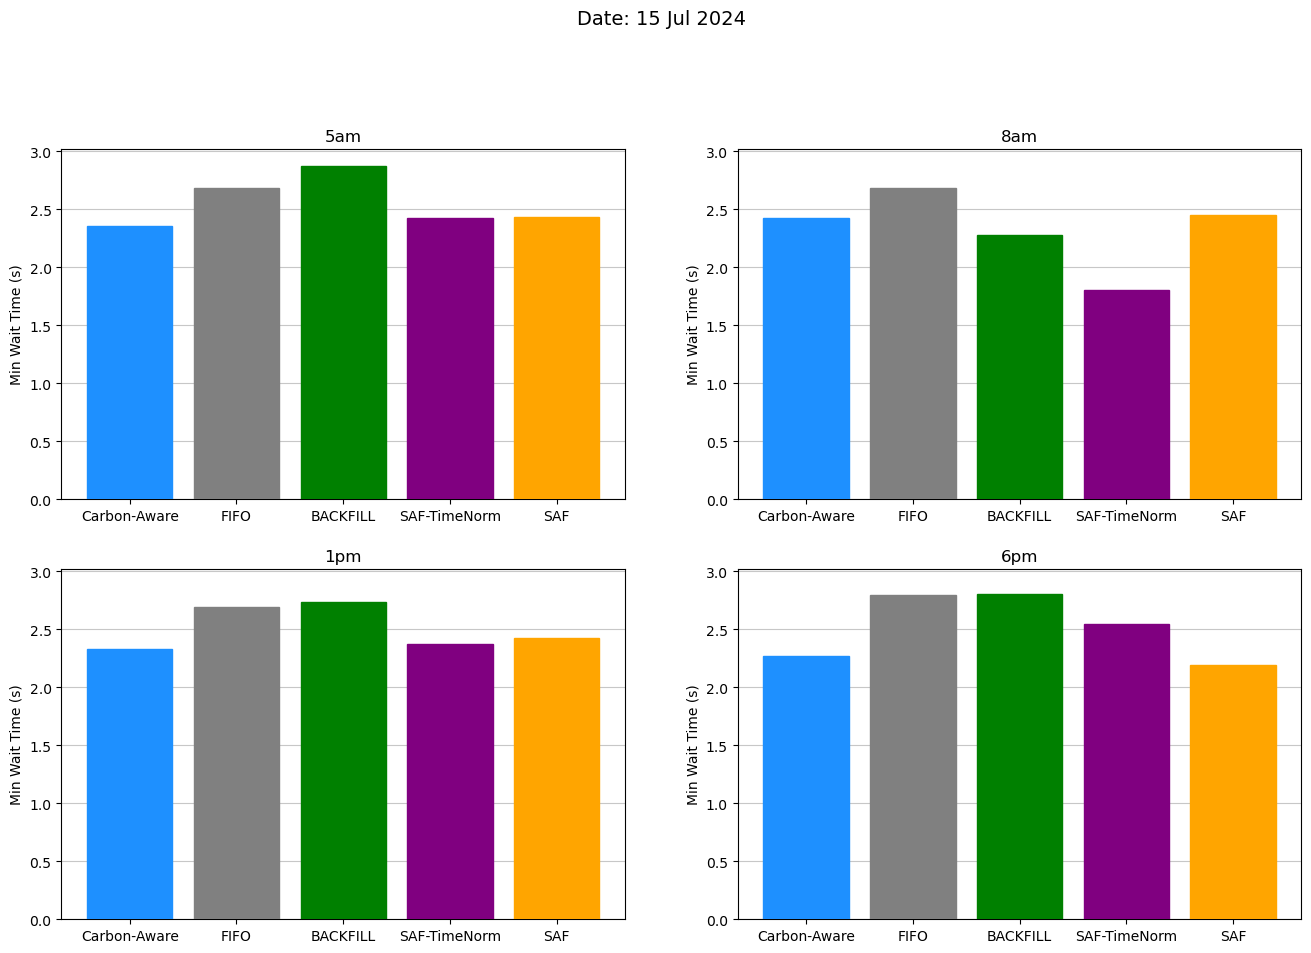

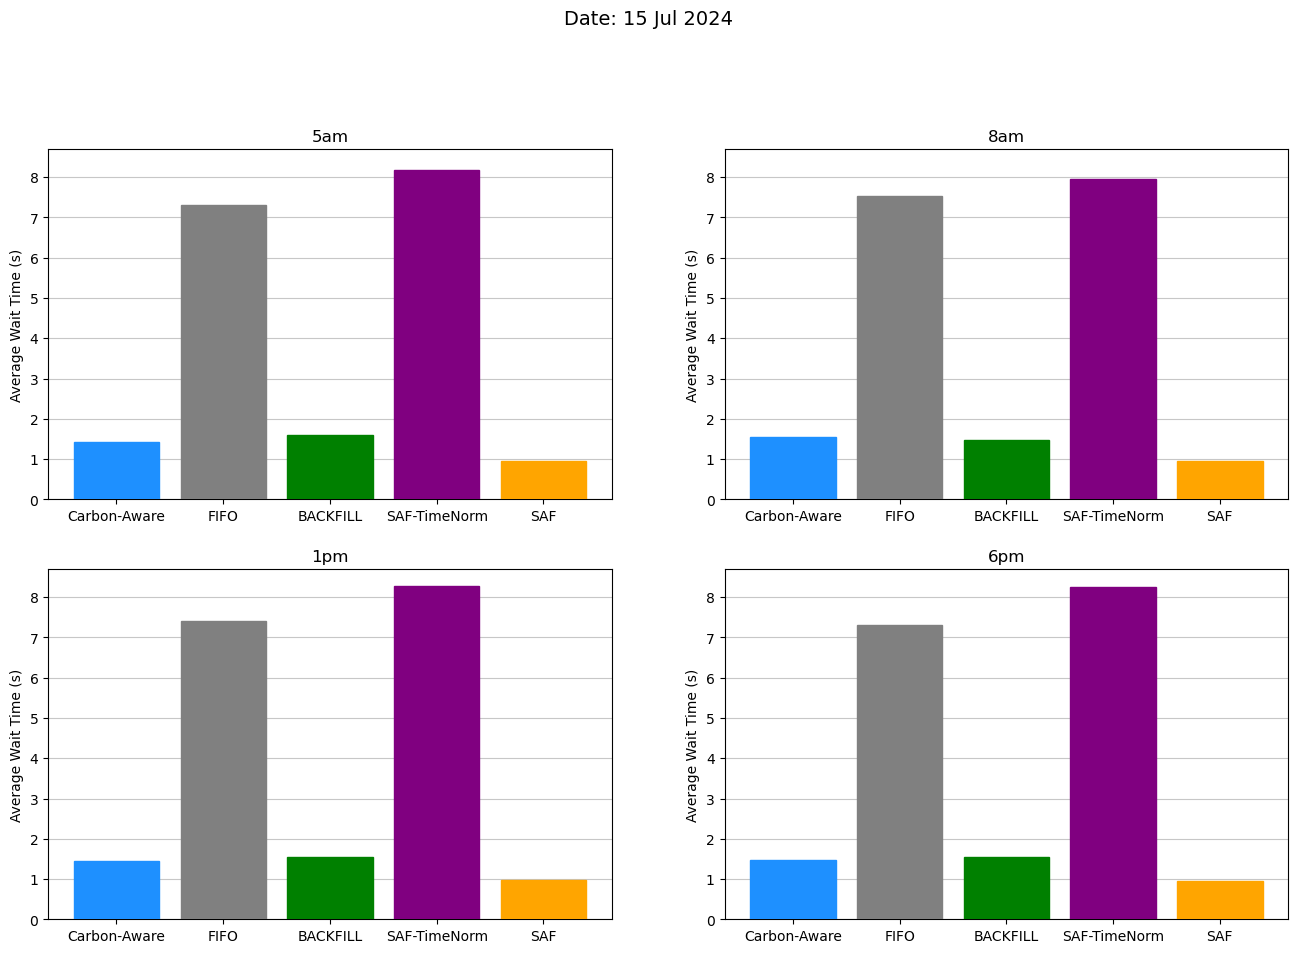

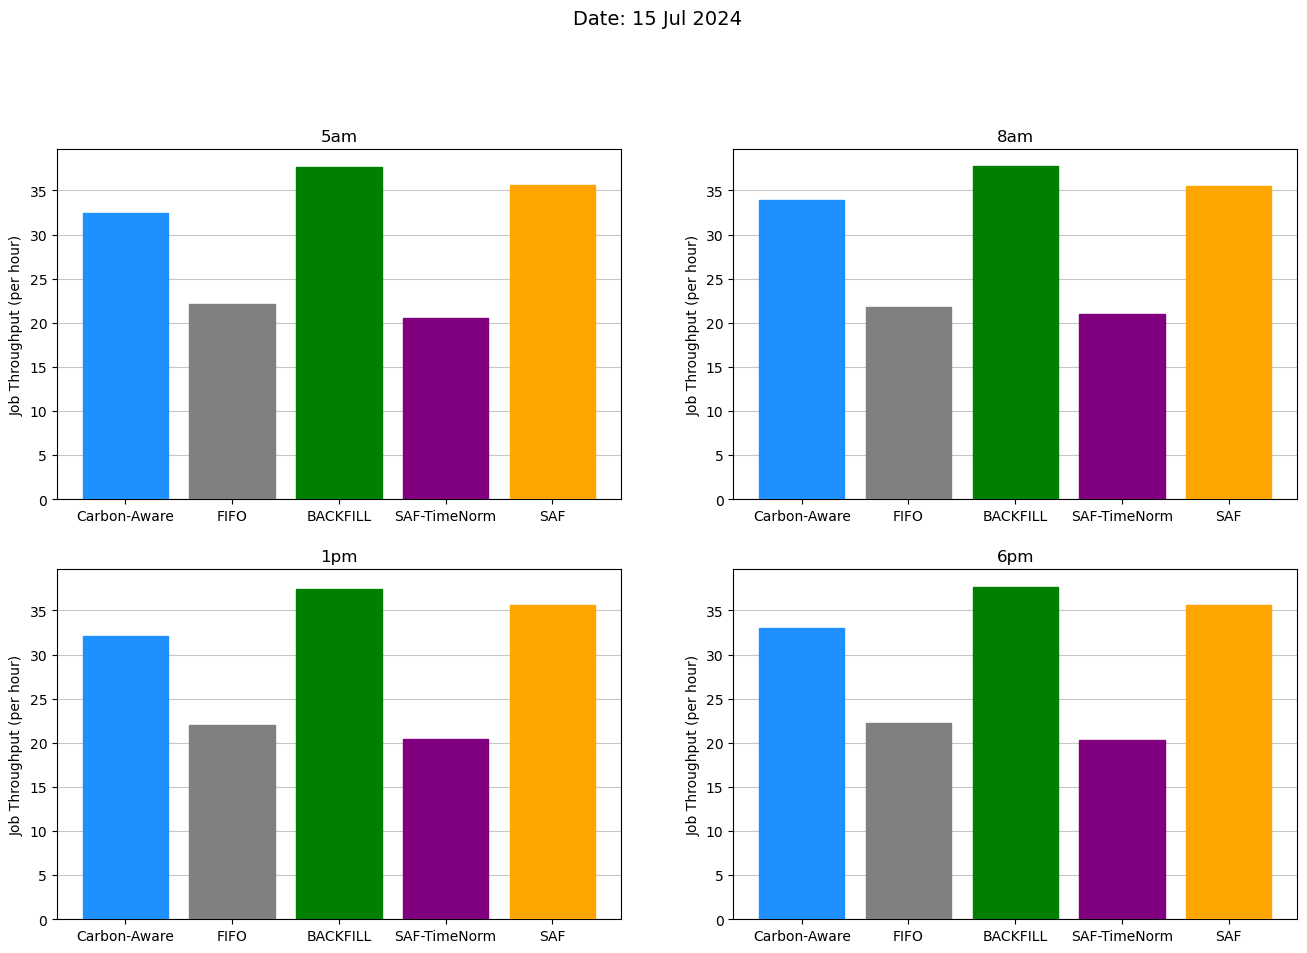

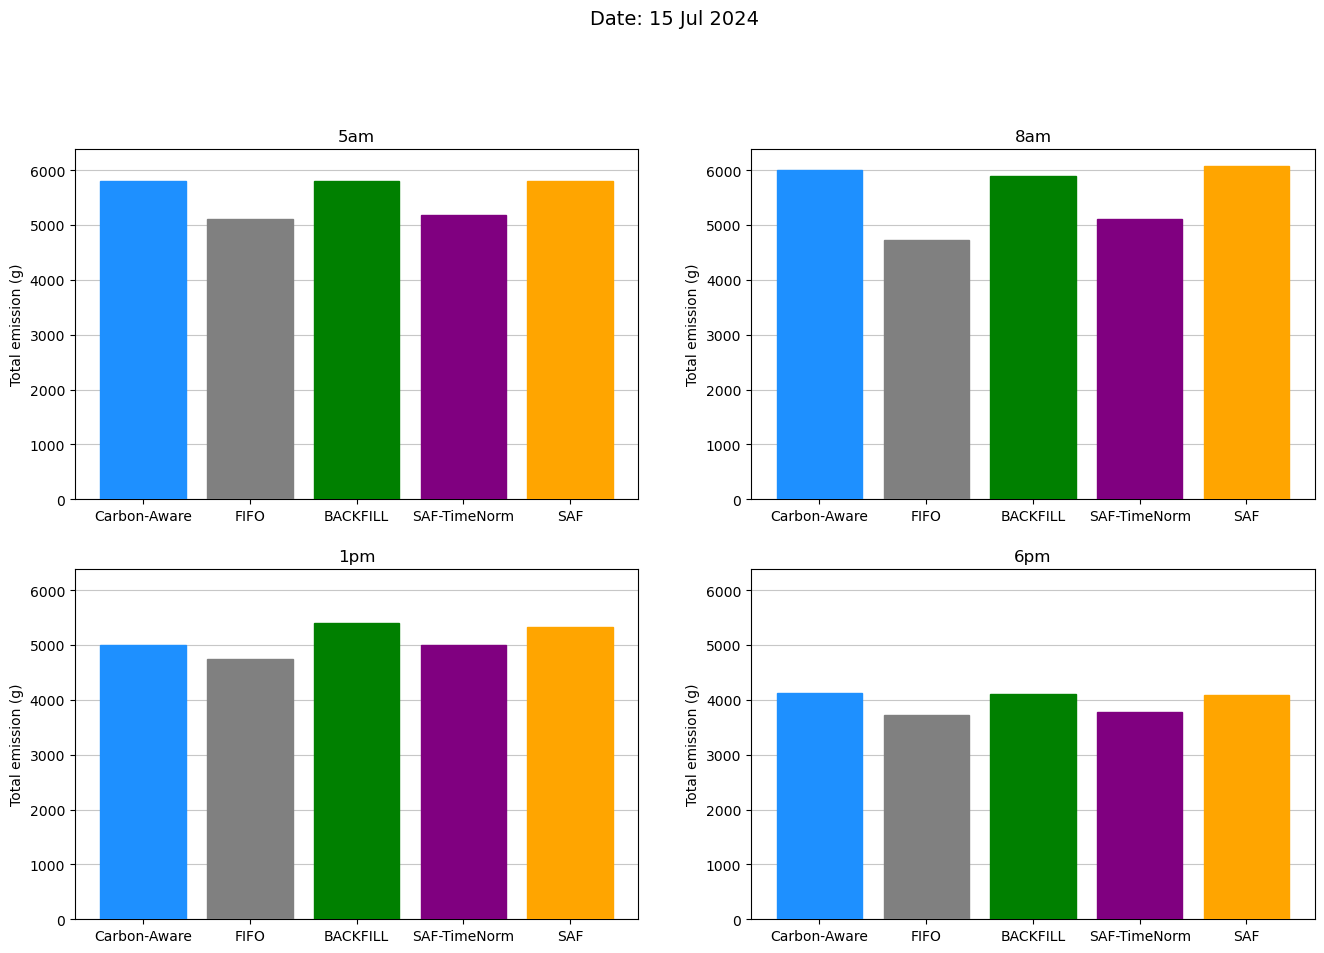

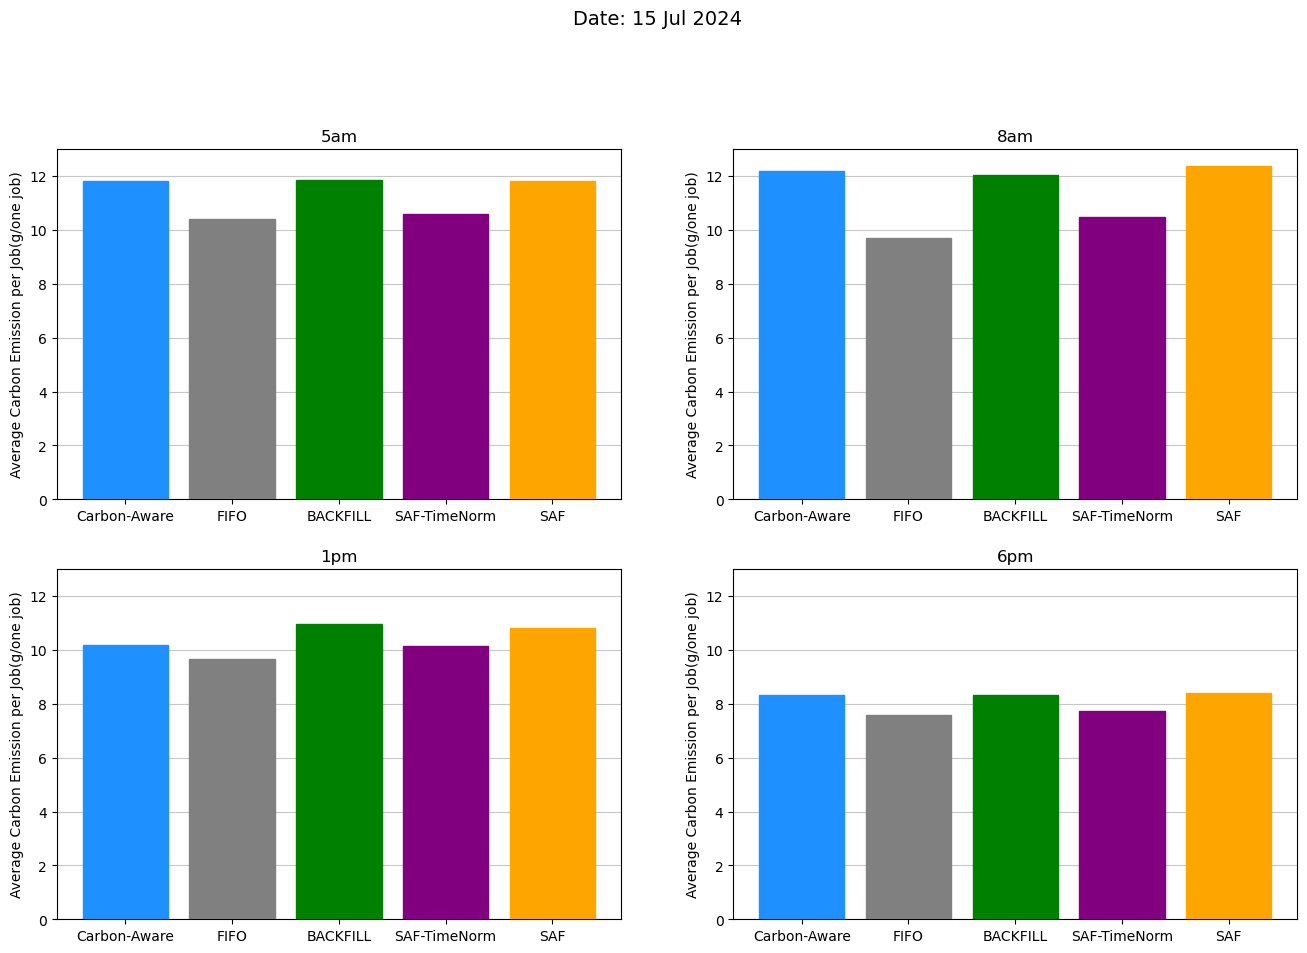

In [8]:
# 2024-07-15

ci_dir_5am_0715 = "result/0715_ci_5am_slurmctld_log.csv"
backfill_dir_5am_0715 = "result/0715_backfill_5am_slurmctld_log.csv"
fifo_dir_5am_0715 =  "result/0715_fifo_5am_slurmctld_log.csv"
saf_timenorm_dir_5am_0715 = "result/0715_saf_timenorm_5am_slurmctld_log.csv"
saf_dir_5am_0715 = "result/0715_saf_5am_slurmctld_log.csv"
ci_result_5am_0715 = calculate_metrics(ci_dir_5am_0715)
fifo_result_5am_0715 = calculate_metrics(fifo_dir_5am_0715)
backfill_result_5am_0715 = calculate_metrics(backfill_dir_5am_0715)
saf_timenorm_result_5am_0715 = calculate_metrics(saf_timenorm_dir_5am_0715)
saf_result_5am_0715 = calculate_metrics(saf_dir_5am_0715)

ci_dir_8am_0715 = "result/0715_ci_8am_slurmctld_log.csv"
backfill_dir_8am_0715 = "result/0715_backfill_8am_slurmctld_log.csv"
fifo_dir_8am_0715 =  "result/0715_fifo_8am_slurmctld_log.csv"
saf_timenorm_dir_8am_0715 = "result/0715_saf_timenorm_8am_slurmctld_log.csv"
saf_dir_8am_0715 = "result/0715_saf_8am_slurmctld_log.csv"
ci_result_8am_0715 = calculate_metrics(ci_dir_8am_0715)
fifo_result_8am_0715 = calculate_metrics(fifo_dir_8am_0715)
backfill_result_8am_0715 = calculate_metrics(backfill_dir_8am_0715)
saf_timenorm_result_8am_0715 = calculate_metrics(saf_timenorm_dir_8am_0715)
saf_result_8am_0715 = calculate_metrics(saf_dir_8am_0715)

ci_dir_1pm_0715 = "result/0715_ci_1pm_slurmctld_log.csv"
backfill_dir_1pm_0715 = "result/0715_backfill_1pm_slurmctld_log.csv"
fifo_dir_1pm_0715 =  "result/0715_fifo_1pm_slurmctld_log.csv"
saf_timenorm_dir_1pm_0715 = "result/0715_saf_timenorm_1pm_slurmctld_log.csv"
saf_dir_1pm_0715 = "result/0715_saf_1pm_slurmctld_log.csv"
ci_result_1pm_0715 = calculate_metrics(ci_dir_1pm_0715)
fifo_result_1pm_0715 = calculate_metrics(fifo_dir_1pm_0715)
backfill_result_1pm_0715 = calculate_metrics(backfill_dir_1pm_0715)
saf_timenorm_result_1pm_0715 = calculate_metrics(saf_timenorm_dir_1pm_0715)
saf_result_1pm_0715 = calculate_metrics(saf_dir_1pm_0715)

ci_dir_6pm_0715 = "result/0715_ci_6pm_slurmctld_log.csv"
backfill_dir_6pm_0715 = "result/0715_backfill_6pm_slurmctld_log.csv"
fifo_dir_6pm_0715 =  "result/0715_fifo_6pm_slurmctld_log.csv"
saf_timenorm_dir_6pm_0715 = "result/0715_saf_timenorm_6pm_slurmctld_log.csv"
saf_dir_6pm_0715 = "result/0715_saf_6pm_slurmctld_log.csv"
ci_result_6pm_0715 = calculate_metrics(ci_dir_6pm_0715)
fifo_result_6pm_0715 = calculate_metrics(fifo_dir_6pm_0715)
backfill_result_6pm_0715 = calculate_metrics(backfill_dir_6pm_0715)
saf_timenorm_result_6pm_0715 = calculate_metrics(saf_timenorm_dir_6pm_0715)
saf_result_6pm_0715 = calculate_metrics(saf_dir_6pm_0715)


index = ['Carbon-Aware', 'FIFO', 'BACKFILL', 'SAF-TimeNorm','SAF']
colors = ['dodgerblue','gray','green','purple','orange']
results_5am_0715 = {'ci': ci_result_5am_0715,'fifo':fifo_result_5am_0715,'backfill':backfill_result_5am_0715,
               'saf_timenorm':saf_timenorm_result_5am_0715,'saf':saf_result_5am_0715}

results_8am_0715 = {'ci': ci_result_8am_0715,'fifo':fifo_result_8am_0715,'backfill':backfill_result_8am_0715,
               'saf_timenorm':saf_timenorm_result_8am_0715,'saf':saf_result_8am_0715}

results_1pm_0715 = {'ci': ci_result_1pm_0715,'fifo':fifo_result_1pm_0715,'backfill':backfill_result_1pm_0715,
               'saf_timenorm':saf_timenorm_result_1pm_0715,'saf':saf_result_1pm_0715}

results_6pm_0715 = {'ci': ci_result_6pm_0715,'fifo':fifo_result_6pm_0715,'backfill':backfill_result_6pm_0715,
               'saf_timenorm':saf_timenorm_result_6pm_0715,'saf':saf_result_6pm_0715}

results_0715 = [results_5am_0715, results_8am_0715, results_1pm_0715, results_6pm_0715]
time_labels = ['5am', '8am', '1pm', '6pm'] 

#2024-07-15
#completion time comparison
draw_chart(index,colors, 'total_completion_time', 'Completion Time (s)', results_0715, time_labels, "Date: 15 Jul 2024")
#waiting time comparison
draw_chart(index,colors, 'total_waiting_time_sum', 'Wait Time (s)', results_0715, time_labels, "Date: 15 Jul 2024")
#max waiting time comparison
draw_chart(index,colors, 'max_waiting_time', 'Max Wait Time (s)', results_0715, time_labels, "Date: 15 Jul 2024")
#min waiting time comparison
draw_chart(index,colors, 'min_waiting_time', 'Min Wait Time (s)', results_0715, time_labels, "Date: 15 Jul 2024")
#average waiting time comparison
draw_chart(index,colors, 'average_waiting_time', 'Average Wait Time (s)', results_0715, time_labels, "Date: 15 Jul 2024")
#job throughput comparison
draw_chart(index,colors, 'job_throughput_per_h', 'Job Throughput (per hour)', results_0715, time_labels, "Date: 15 Jul 2024")
#total emissions comparison
draw_chart(index,colors, 'total_emissions_sum', 'Total emission (g)', results_0715, time_labels, "Date: 15 Jul 2024")
#average carbon emissions 
draw_chart(index,colors, 'emissions_rate_per_job', 'Average Carbon Emission per Job(g/one job)', results_0715, time_labels, "Date: 15 Jul 2024")





